In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt

# Loading the Data set
df = pd.read_csv("/kaggle/input/datasets/rohitsahoo/sales-forecasting/train.csv")


In [2]:
df.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [4]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [5]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9795    False
9796    False
9797    False
9798    False
9799    False
Length: 9800, dtype: bool

In [6]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage)

Row ID           0.000000
Order ID         0.000000
Order Date       0.000000
Ship Date        0.000000
Ship Mode        0.000000
Customer ID      0.000000
Customer Name    0.000000
Segment          0.000000
Country          0.000000
City             0.000000
State            0.000000
Postal Code      0.112245
Region           0.000000
Product ID       0.000000
Category         0.000000
Sub-Category     0.000000
Product Name     0.000000
Sales            0.000000
dtype: float64


In [7]:
df.drop(['Order ID','Ship Date','Row ID','Ship Mode','Sub-Category','Postal Code','Customer Name'], axis=1, inplace=True)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    9800 non-null   object 
 1   Customer ID   9800 non-null   object 
 2   Segment       9800 non-null   object 
 3   Country       9800 non-null   object 
 4   City          9800 non-null   object 
 5   State         9800 non-null   object 
 6   Region        9800 non-null   object 
 7   Product ID    9800 non-null   object 
 8   Category      9800 non-null   object 
 9   Product Name  9800 non-null   object 
 10  Sales         9800 non-null   float64
dtypes: float64(1), object(10)
memory usage: 842.3+ KB


In [9]:
df.describe()

,Sales
count,9800.000000
mean,230.769059
std,626.651875
min,0.444000
25%,17.248000
50%,54.490000
75%,210.605000
max,22638.480000


In [10]:
df.head(2)

,Order Date,Customer ID,Segment,Country,City,State,Region,Product ID,Category,Product Name,Sales
0,08/11/2017,CG-12520,Consumer,United States,Henderson,Kentucky,South,FUR-BO-10001798,Furniture,Bush Somerset Collection Bookcase,261.96
1,08/11/2017,CG-12520,Consumer,United States,Henderson,Kentucky,South,FUR-CH-10000454,Furniture,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94


In [11]:
df.shape

(9800, 11)

In [12]:
df.isnull().sum()

Order Date      0
Customer ID     0
Segment         0
Country         0
City            0
State           0
Region          0
Product ID      0
Category        0
Product Name    0
Sales           0
dtype: int64

Convert Date

In [13]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order Date    9800 non-null   datetime64[ns]
 1   Customer ID   9800 non-null   object        
 2   Segment       9800 non-null   object        
 3   Country       9800 non-null   object        
 4   City          9800 non-null   object        
 5   State         9800 non-null   object        
 6   Region        9800 non-null   object        
 7   Product ID    9800 non-null   object        
 8   Category      9800 non-null   object        
 9   Product Name  9800 non-null   object        
 10  Sales         9800 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(9)
memory usage: 842.3+ KB


In [15]:
df.shape

(9800, 11)

In [16]:
df.head(2)

,Order Date,Customer ID,Segment,Country,City,State,Region,Product ID,Category,Product Name,Sales
0,2017-11-08,CG-12520,Consumer,United States,Henderson,Kentucky,South,FUR-BO-10001798,Furniture,Bush Somerset Collection Bookcase,261.96
1,2017-11-08,CG-12520,Consumer,United States,Henderson,Kentucky,South,FUR-CH-10000454,Furniture,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94


In [17]:
daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()
print(daily_sales)

     Order Date      Sales
0    2015-01-03    16.4480
1    2015-01-04   288.0600
2    2015-01-05    19.5360
3    2015-01-06  4407.1000
4    2015-01-07    87.1580
...         ...        ...
1225 2018-12-26   814.5940
1226 2018-12-27   177.6360
1227 2018-12-28  1657.3508
1228 2018-12-29  2915.5340
1229 2018-12-30   713.7900

[1230 rows x 2 columns]


In [18]:
max_sales_date_row = daily_sales.loc[daily_sales['Sales'].idxmax()]
print(max_sales_date_row)

Order Date    2015-03-18 00:00:00
Sales                   28106.716
Name: 53, dtype: object


In [19]:
# 4. Extract the date and sales amount
highest_sales_date = max_sales_date_row['Order Date']
print(highest_sales_date)
highest_sales_amount = max_sales_date_row['Sales']
print(highest_sales_amount)

2015-03-18 00:00:00
28106.716


In [20]:
df['month'] = df['Order Date'].dt.month
df.groupby('month')['Sales'].sum().sort_values(ascending = False)

month
11    350161.7110
12    321480.1695
9     300103.4117
10    199496.2947
3     197573.5872
8     157315.9270
5     154086.7237
6     145837.5233
7     145535.6890
4     136283.0006
1      94291.6296
2      59371.1154
Name: Sales, dtype: float64

In [21]:
# Check Duplicates
df.duplicated().sum
df = df.drop_duplicates()

In [22]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9795    False
9796    False
9797    False
9798    False
9799    False
Length: 9799, dtype: bool

In [23]:
# Check for Hidden Missing Values
df.isnull().sum()

Order Date      0
Customer ID     0
Segment         0
Country         0
City            0
State           0
Region          0
Product ID      0
Category        0
Product Name    0
Sales           0
month           0
dtype: int64

In [24]:
(df == '').sum()

Order Date      0
Customer ID     0
Segment         0
Country         0
City            0
State           0
Region          0
Product ID      0
Category        0
Product Name    0
Sales           0
month           0
dtype: int64

In [25]:
# Check Outliers
df['Sales'].describe()

count     9799.000000
mean       230.763895
std        626.683644
min          0.444000
25%         17.248000
50%         54.480000
75%        210.572000
max      22638.480000
Name: Sales, dtype: float64

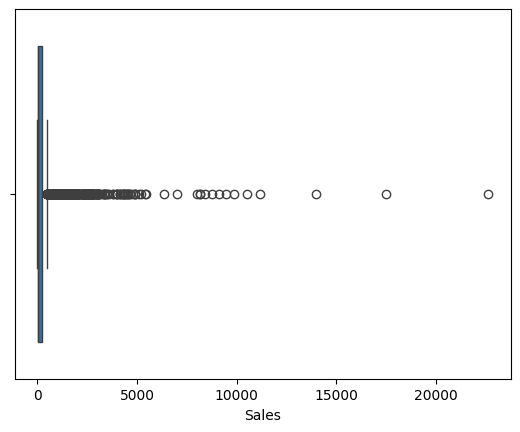

In [26]:
sns.boxplot(x=df['Sales'])
plt.show()

In [27]:
# Using IQR method to check outliers
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)

IQR = Q3-Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR 

outlier = df[(df['Sales']< lower) | (df['Sales'] > upper)]
print(outlier)

     Order Date Customer ID    Segment        Country             City  \
1    2017-11-08    CG-12520   Consumer  United States        Henderson   
3    2016-10-11    SO-20335   Consumer  United States  Fort Lauderdale   
7    2015-06-09    BH-11710   Consumer  United States      Los Angeles   
10   2015-06-09    BH-11710   Consumer  United States      Los Angeles   
11   2015-06-09    BH-11710   Consumer  United States      Los Angeles   
...         ...         ...        ...            ...              ...   
9759 2017-10-31    SF-20965  Corporate  United States    San Francisco   
9774 2015-07-26    LF-17185   Consumer  United States      San Antonio   
9781 2017-09-14    CL-12565   Consumer  United States       Long Beach   
9787 2018-03-27    CJ-12010   Consumer  United States          Houston   
9788 2018-03-27    CJ-12010   Consumer  United States          Houston   

           State   Region       Product ID         Category  \
1       Kentucky    South  FUR-CH-10000454      

Using Z-Score (For Normal Distribution)
Works when data is normally distributed

In [28]:
from scipy import stats

z = stats.zscore(df['Sales'])

outliers = df[(z > 3) | (z < -3)]
print(outliers)


     Order Date Customer ID      Segment        Country           City  \
27   2016-09-17    TB-21520     Consumer  United States   Philadelphia   
165  2015-09-08    BM-11140     Consumer  United States    San Antonio   
251  2017-09-11    KC-16540     Consumer  United States      San Diego   
262  2015-09-19    SB-20290    Corporate  United States        Houston   
263  2015-09-19    SB-20290    Corporate  United States        Houston   
...         ...         ...          ...            ...            ...   
9639 2016-01-28    JH-15985     Consumer  United States        Concord   
9649 2017-11-26    MS-17365     Consumer  United States    Los Angeles   
9660 2017-06-06    ME-17320  Home Office  United States  Santa Barbara   
9741 2016-11-08    QJ-19255    Corporate  United States     Burlington   
9774 2015-07-26    LF-17185     Consumer  United States    San Antonio   

               State   Region       Product ID         Category  \
27      Pennsylvania     East  FUR-BO-100048

In [29]:
# Remove Outliers (Simple way)
df_clean = df[(df['Sales']>= lower) & (df['Sales'] <= upper)]

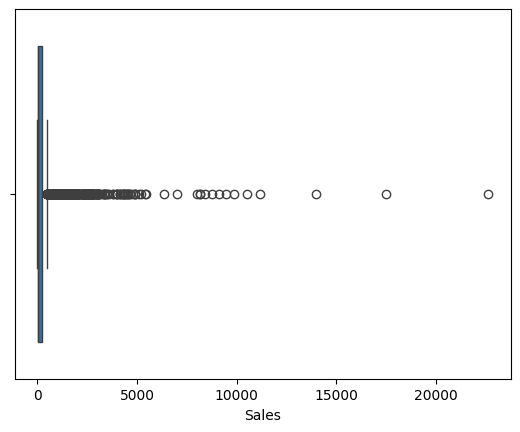

In [30]:
sns.boxplot(x=df['Sales'])
plt.show()

In [31]:
# Cap (Winsorization)
# Instead of deleting, we limit extreme values
df['Sales'] = df['Sales'].clip(lower, upper)

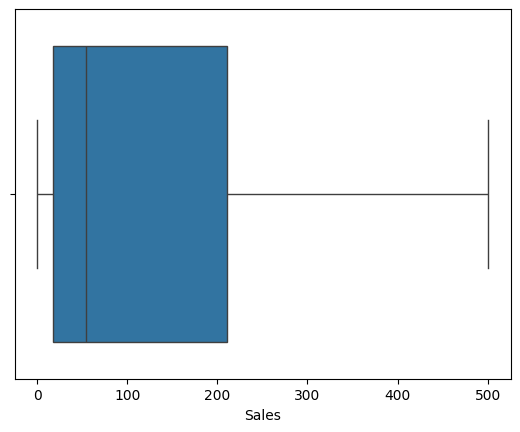

In [32]:
sns.boxplot(x=df['Sales'])
plt.show()

In [33]:
df['Sales'] = np.log(df['Sales'])

In [34]:
# Extact Years and Months
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Day'] = df['Order Date'].dt.date

In [35]:
df.describe()

,Order Date,Sales,month,Year,Month
count,9799,9799.000000,9799.000000,9799.000000,9799.000000
mean,2017-05-01 07:02:29.525461760,4.029694,7.818859,2016.724360,7.818859
min,2015-01-03 00:00:00,-0.811931,1.000000,2015.000000,1.000000
25%,2016-05-24 12:00:00,2.847696,5.000000,2016.000000,5.000000
50%,2017-06-26 00:00:00,3.997834,9.000000,2017.000000,9.000000
75%,2018-05-15 00:00:00,5.349828,11.000000,2018.000000,11.000000
max,2018-12-30 00:00:00,6.215723,12.000000,2018.000000,12.000000
std,NaN,1.504583,3.281846,1.123906,3.281846


In [36]:
print(df.columns)

Index(['Order Date', 'Customer ID', 'Segment', 'Country', 'City', 'State',
       'Region', 'Product ID', 'Category', 'Product Name', 'Sales', 'month',
       'Year', 'Month', 'Day'],
      dtype='object')
